In [2]:
import subprocess
result = subprocess.run(
    ['pip', 'install', 'pyriemann', '--quiet'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)
print("pyriemann installed")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

pyriemann installed


In [3]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import mne
from sklearn.decomposition import PCA

from src.riemannian import (
    extract_riemannian_features,
    save_riemannian_features,
    load_riemannian_features,
    visualize_riemannian,
    CLASS_NAMES
)

In [4]:
import os

subjects     = ['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']
LOAD_PATH    = '../data/processed/'
SAVE_PATH    = '../data/features_riemannian/'
FIGURES_PATH = '../results/figures/features/riemannian/'

os.makedirs(SAVE_PATH,    exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

print("Paths ready")

Paths ready



  A01T
  No bad trials found
  X shape:        (164, 22, 751)
  y distribution: [44 61 33 26]
  Covariance matrices shape: (164, 22, 22)
  Tangent space features shape: (164, 253)
  Saved to ../data/features_riemannian/A01T_riemannian.npz
  Generating Riemannian plots for A01T...


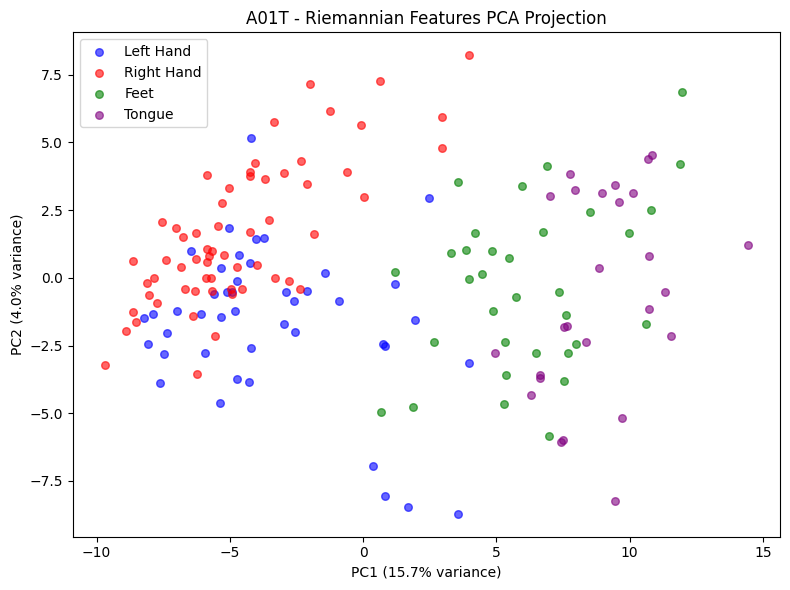

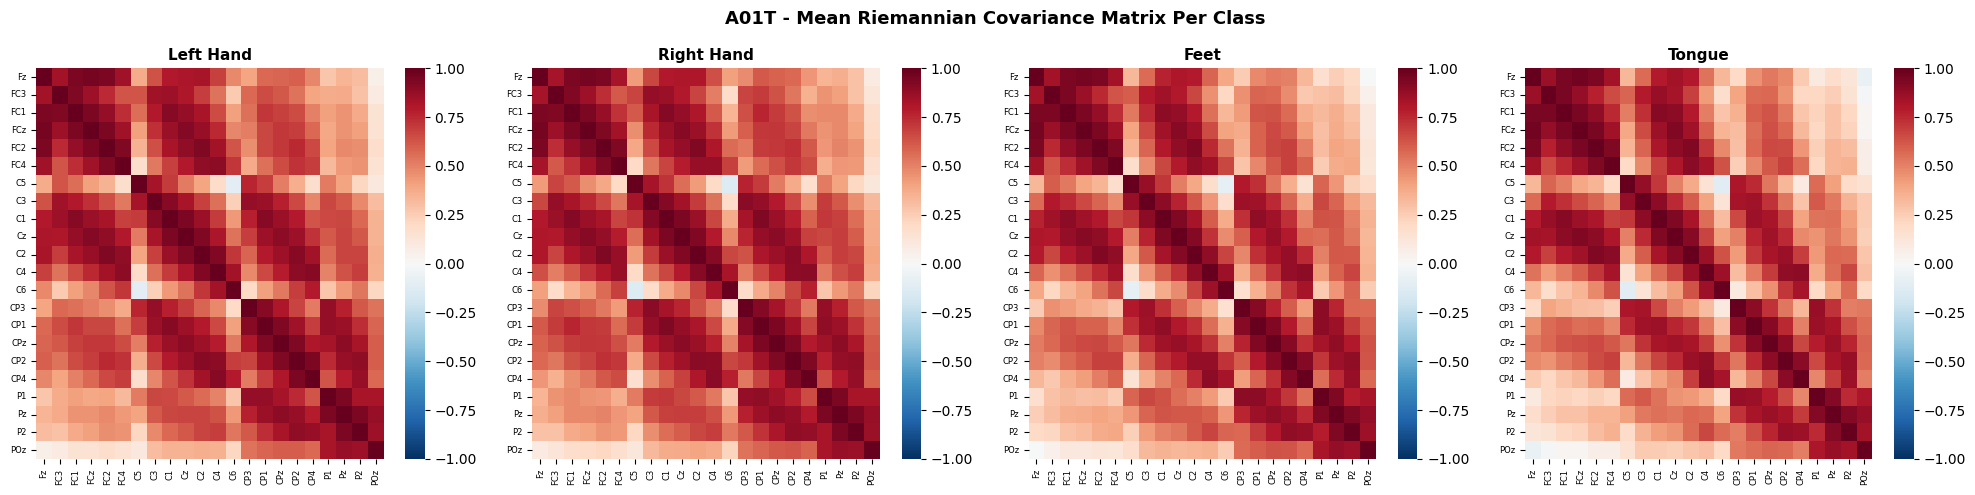

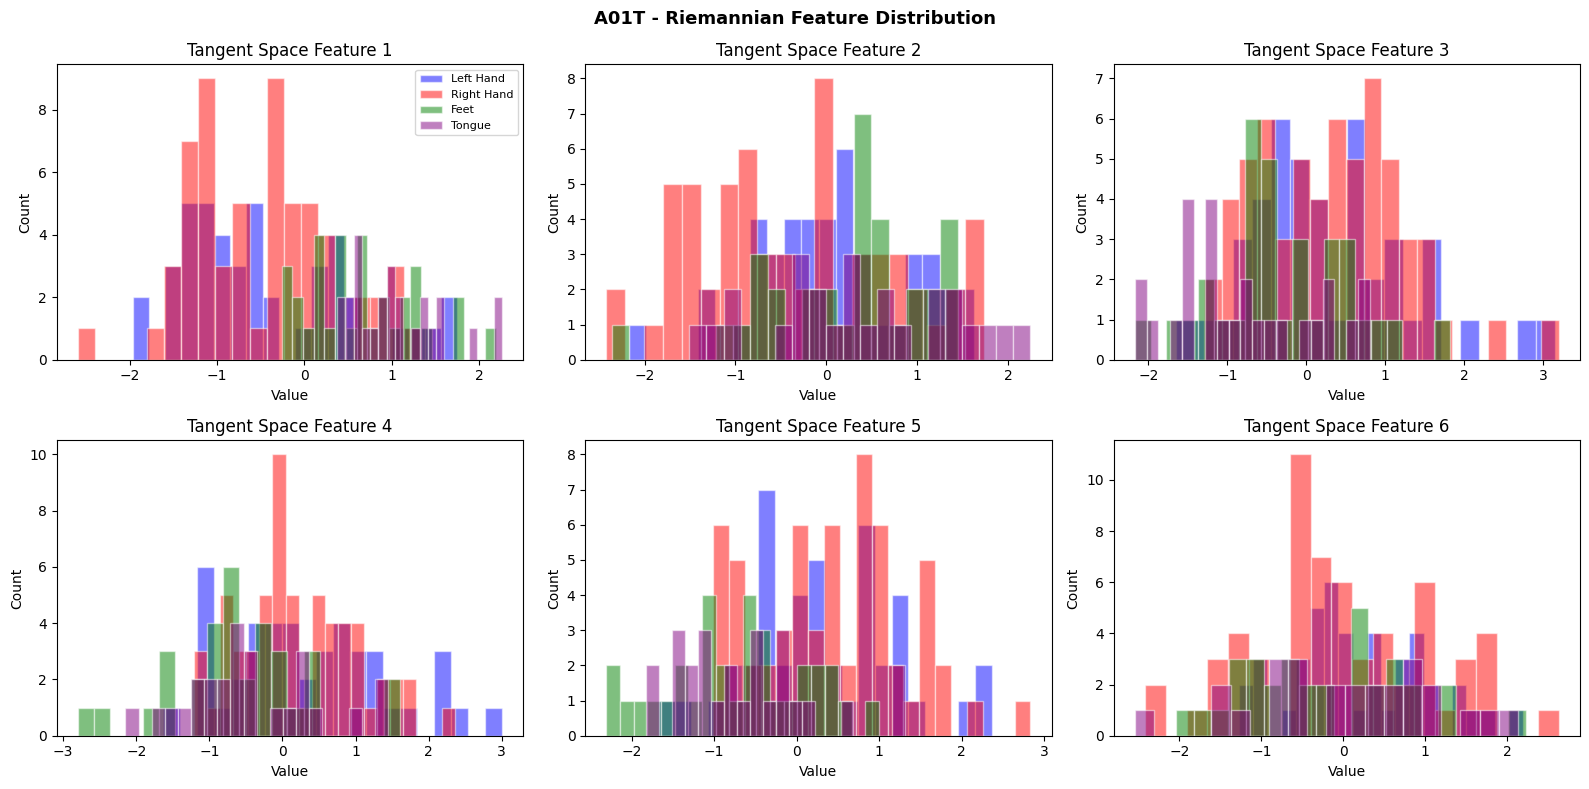

  Plots saved for A01T
  Done: A01T

  A02T
  No bad trials found
  X shape:        (216, 22, 751)
  y distribution: [55 56 49 56]
  Covariance matrices shape: (216, 22, 22)
  Tangent space features shape: (216, 253)
  Saved to ../data/features_riemannian/A02T_riemannian.npz
  Generating Riemannian plots for A02T...


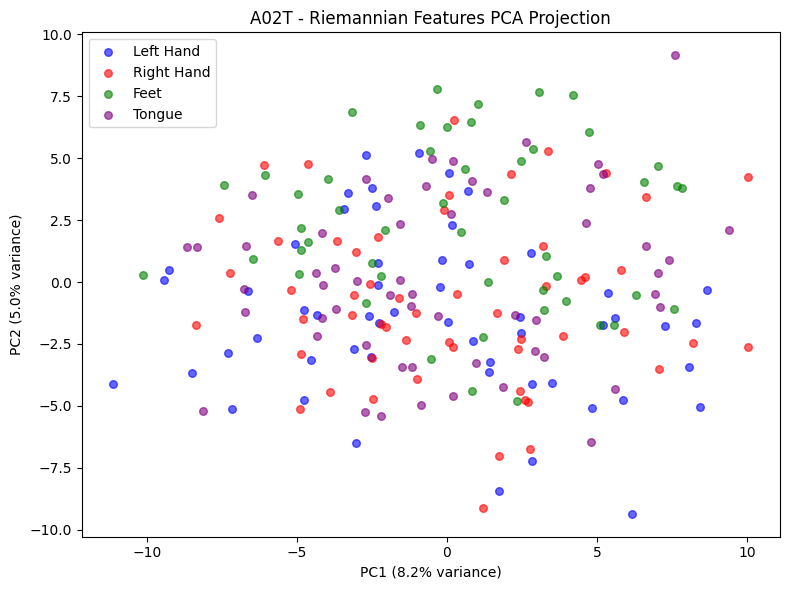

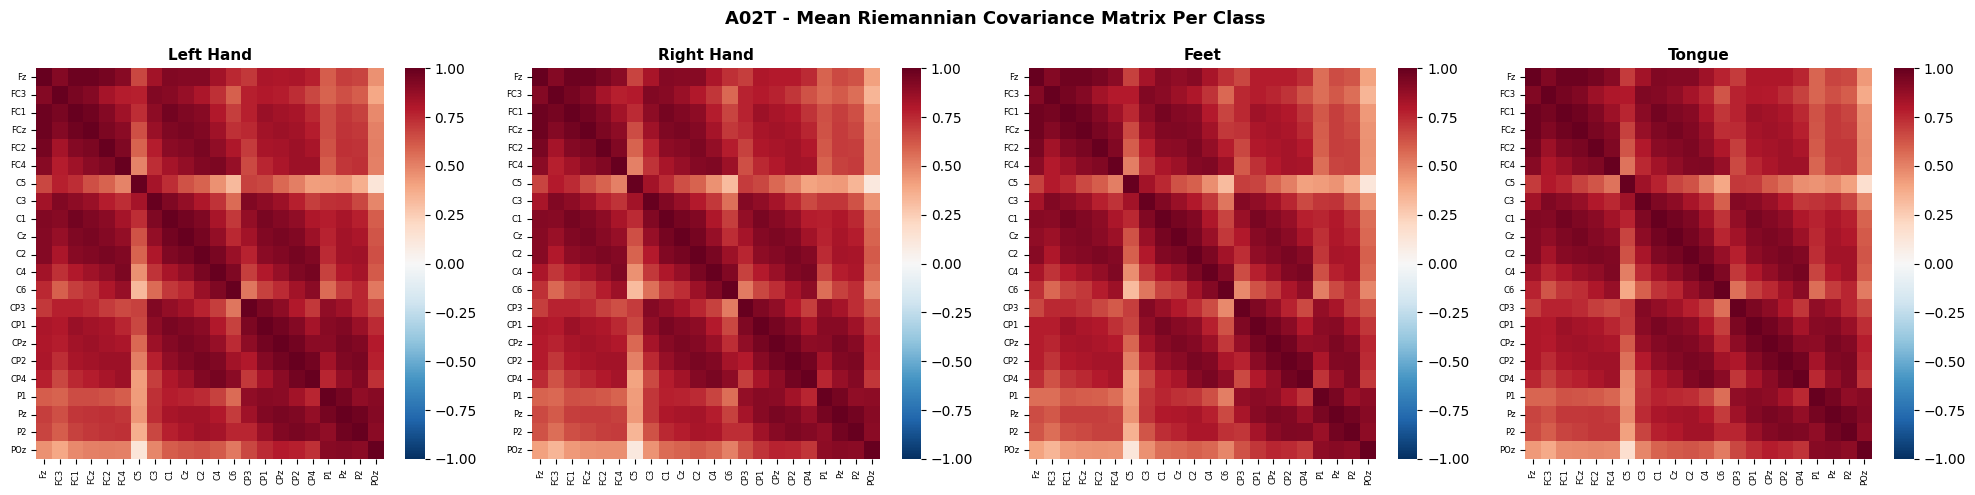

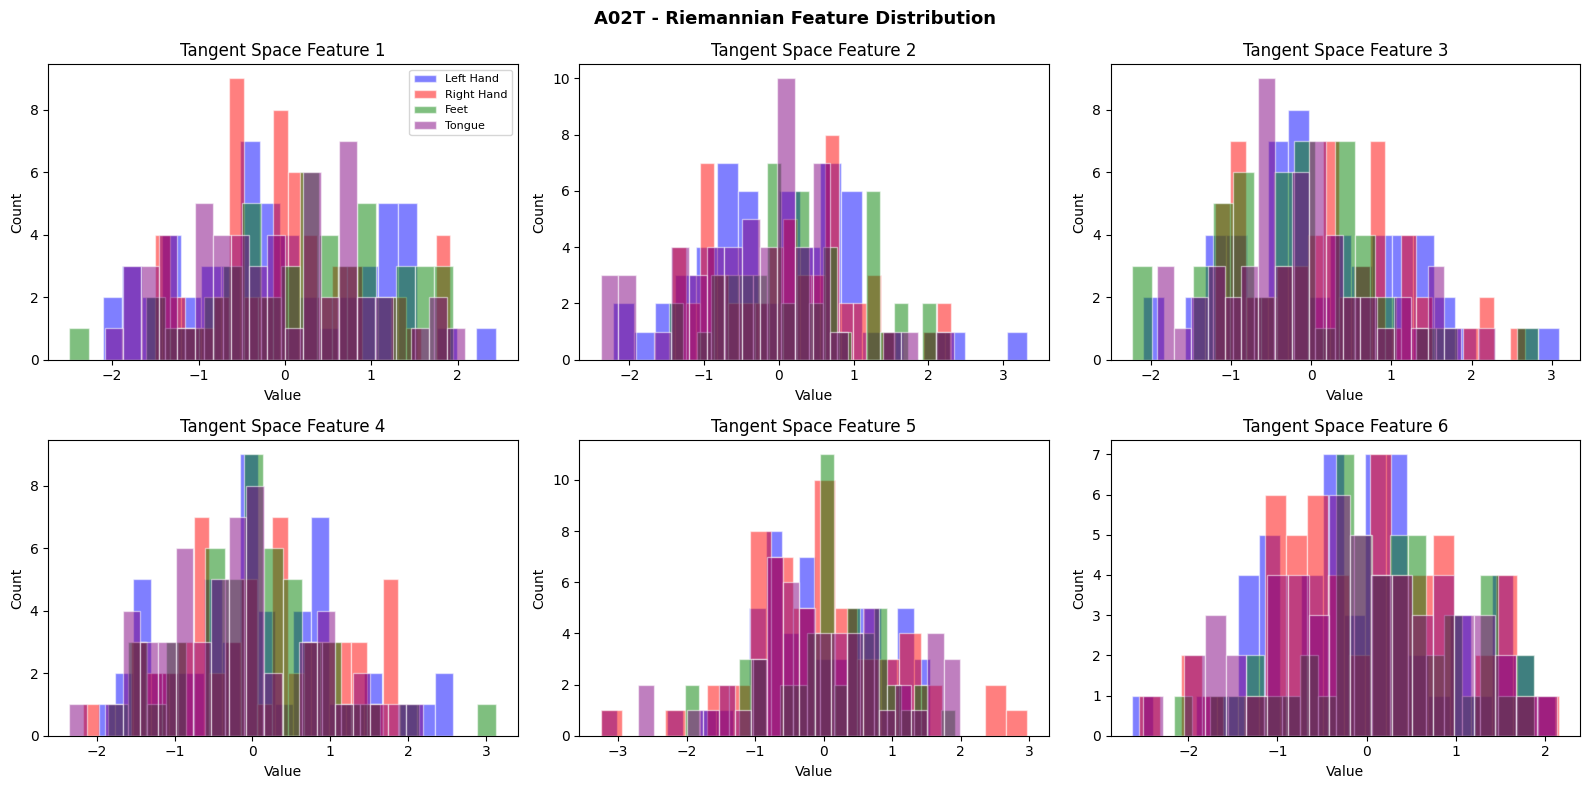

  Plots saved for A02T
  Done: A02T

  A03T
  No bad trials found
  X shape:        (179, 22, 751)
  y distribution: [41 51 47 40]
  Covariance matrices shape: (179, 22, 22)
  Tangent space features shape: (179, 253)
  Saved to ../data/features_riemannian/A03T_riemannian.npz
  Generating Riemannian plots for A03T...


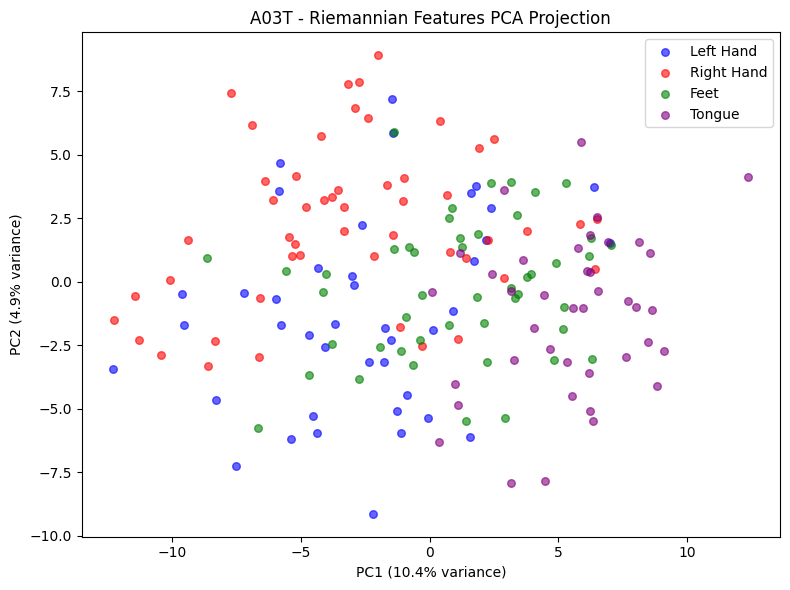

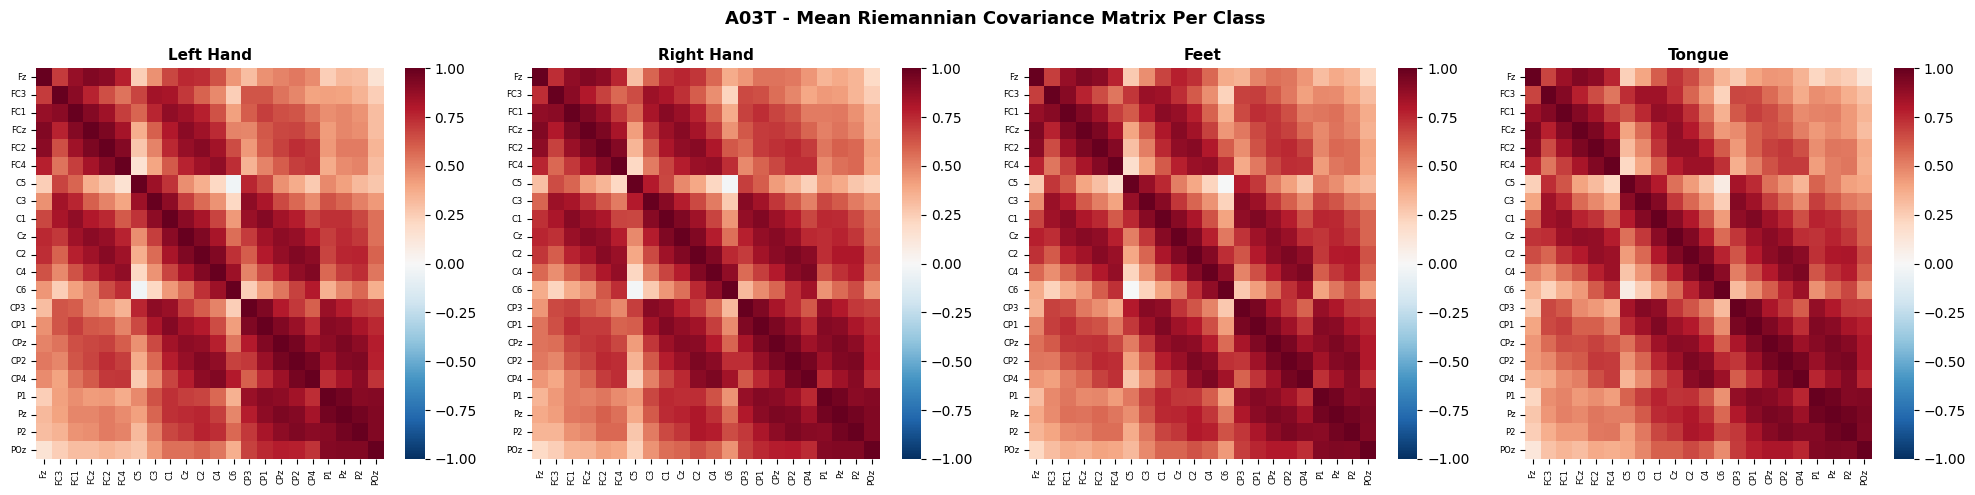

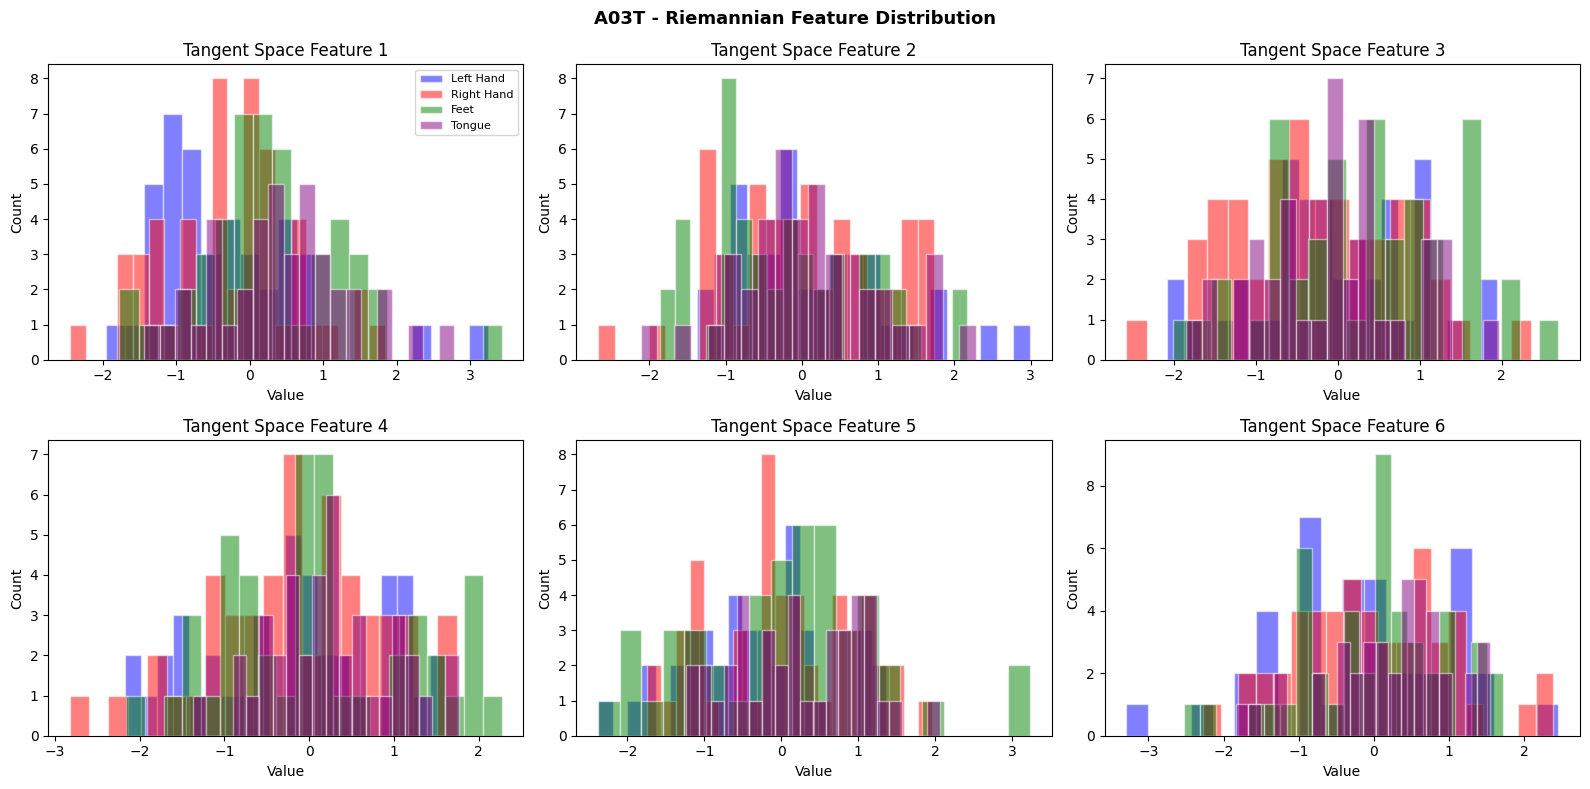

  Plots saved for A03T
  Done: A03T

  A04T
  No bad trials found
  X shape:        (262, 22, 751)
  y distribution: [67 63 64 68]
  Covariance matrices shape: (262, 22, 22)
  Tangent space features shape: (262, 253)
  Saved to ../data/features_riemannian/A04T_riemannian.npz
  Generating Riemannian plots for A04T...


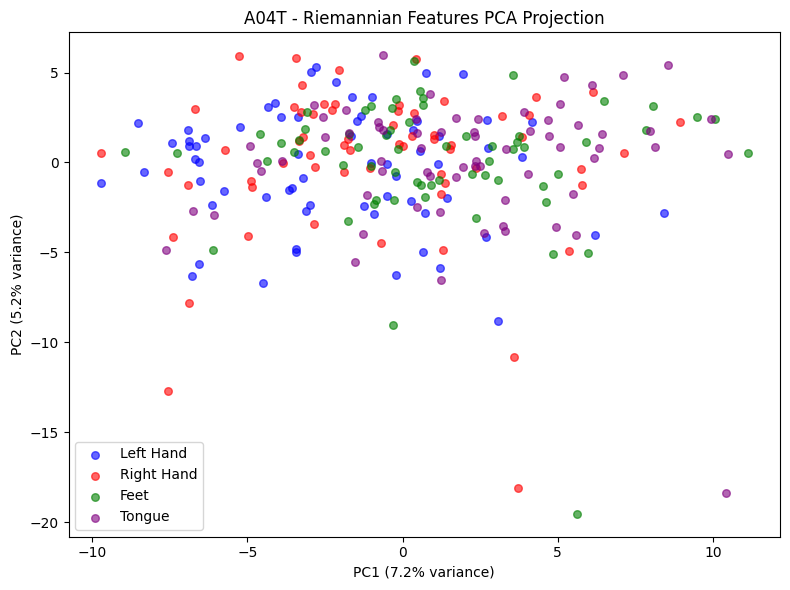

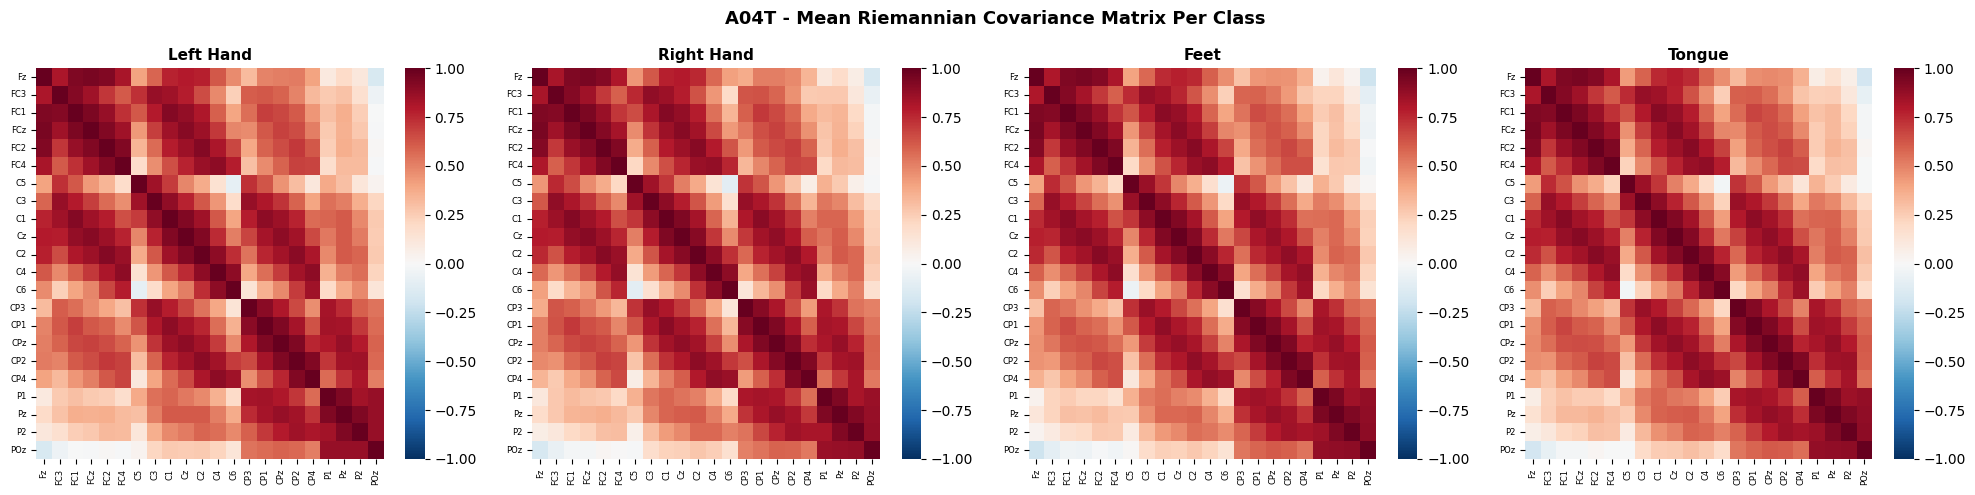

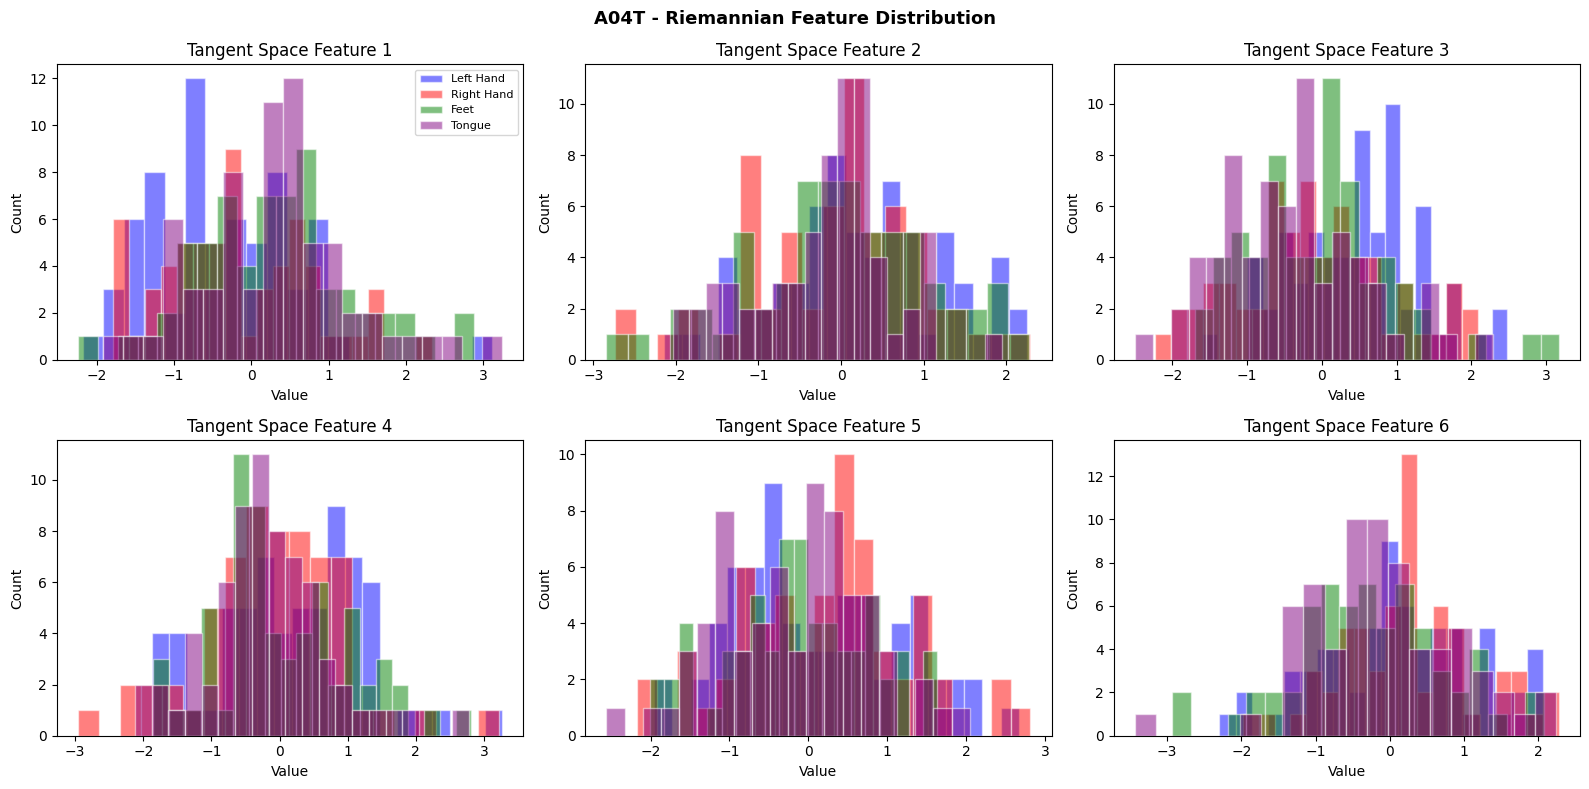

  Plots saved for A04T
  Done: A04T

  A05T
  No bad trials found
  X shape:        (127, 22, 751)
  y distribution: [30 33 22 42]
  Covariance matrices shape: (127, 22, 22)
  Tangent space features shape: (127, 253)
  Saved to ../data/features_riemannian/A05T_riemannian.npz
  Generating Riemannian plots for A05T...


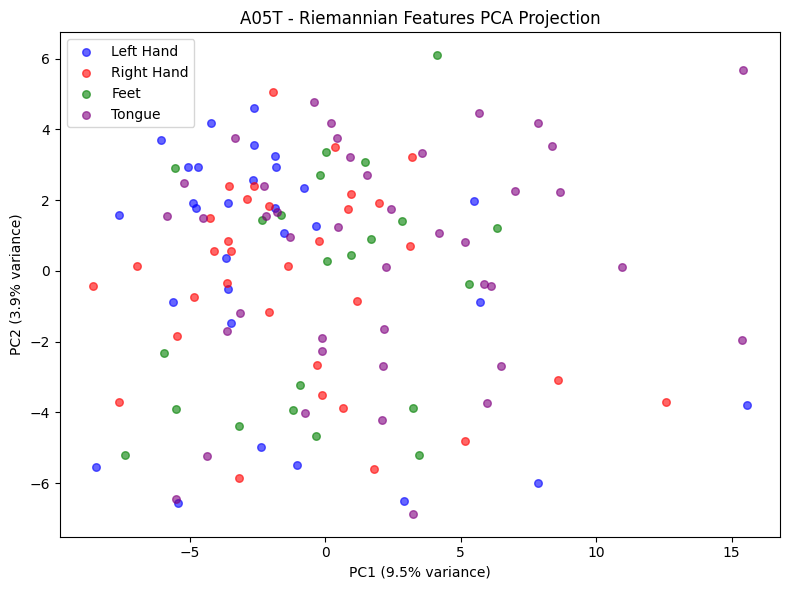

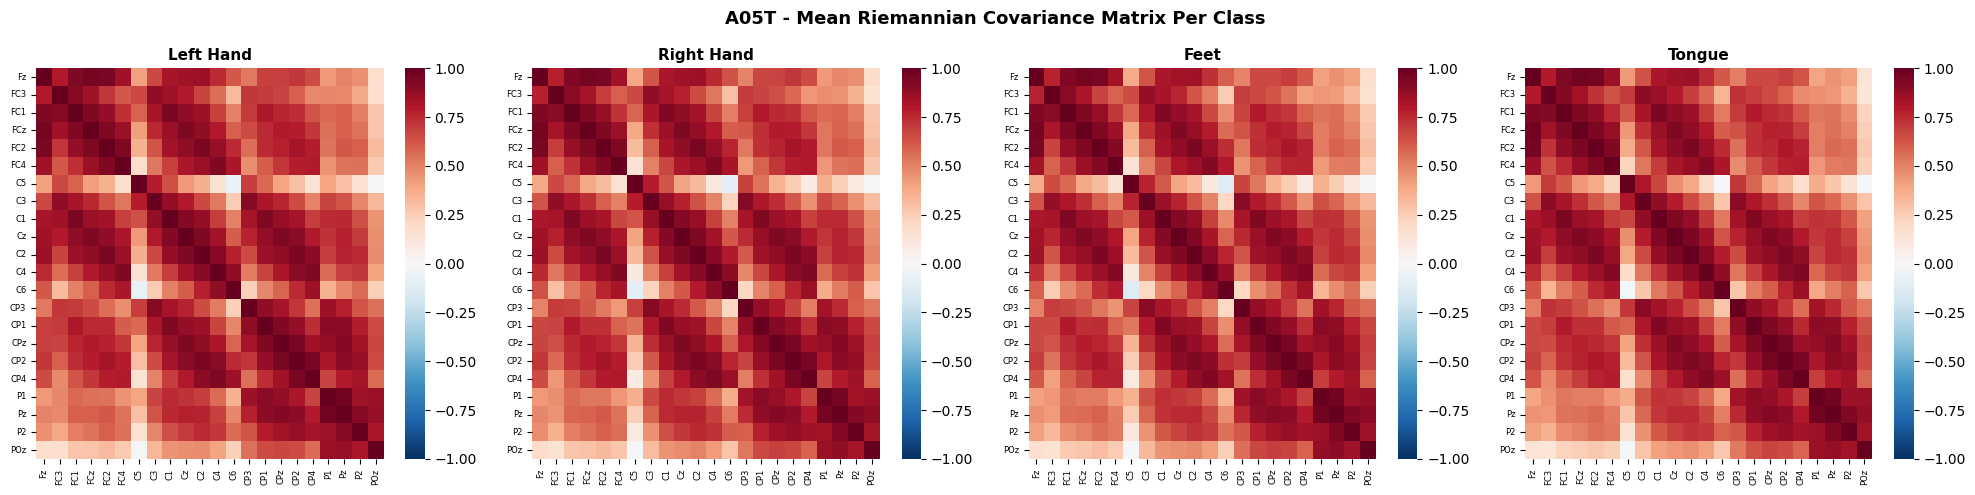

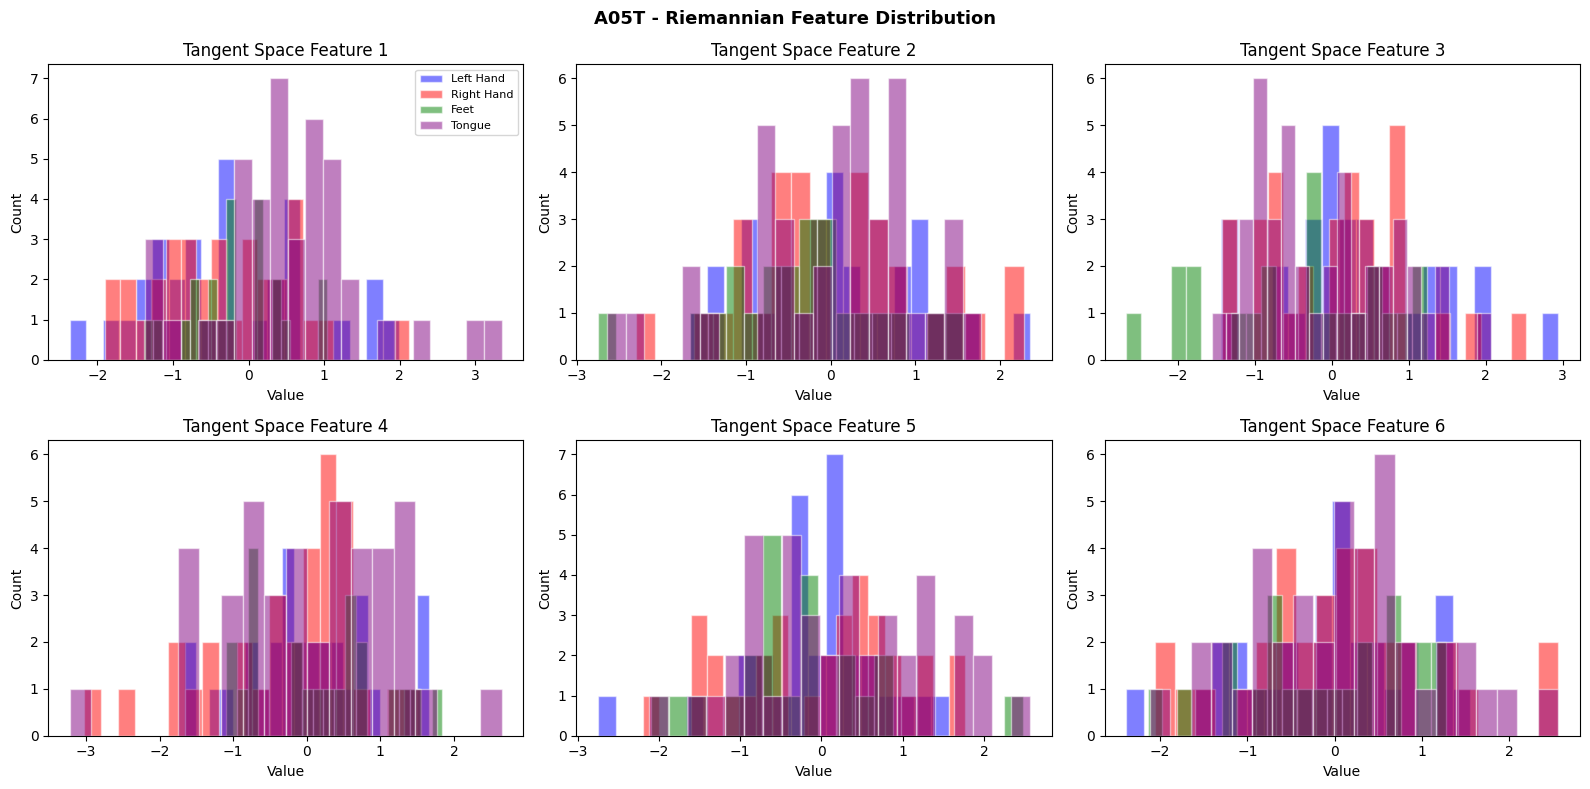

  Plots saved for A05T
  Done: A05T

  A06T
  No bad trials found
  X shape:        (282, 22, 751)
  y distribution: [72 69 70 71]
  Covariance matrices shape: (282, 22, 22)
  Tangent space features shape: (282, 253)
  Saved to ../data/features_riemannian/A06T_riemannian.npz
  Generating Riemannian plots for A06T...


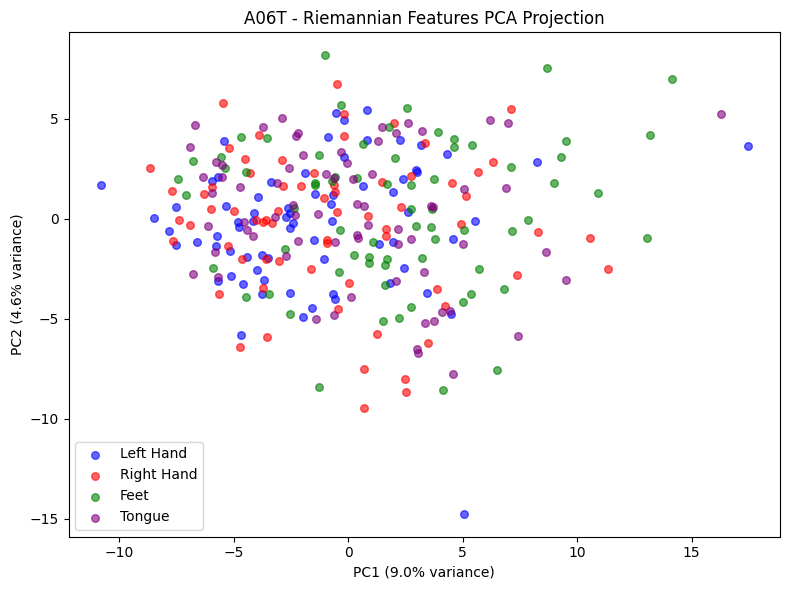

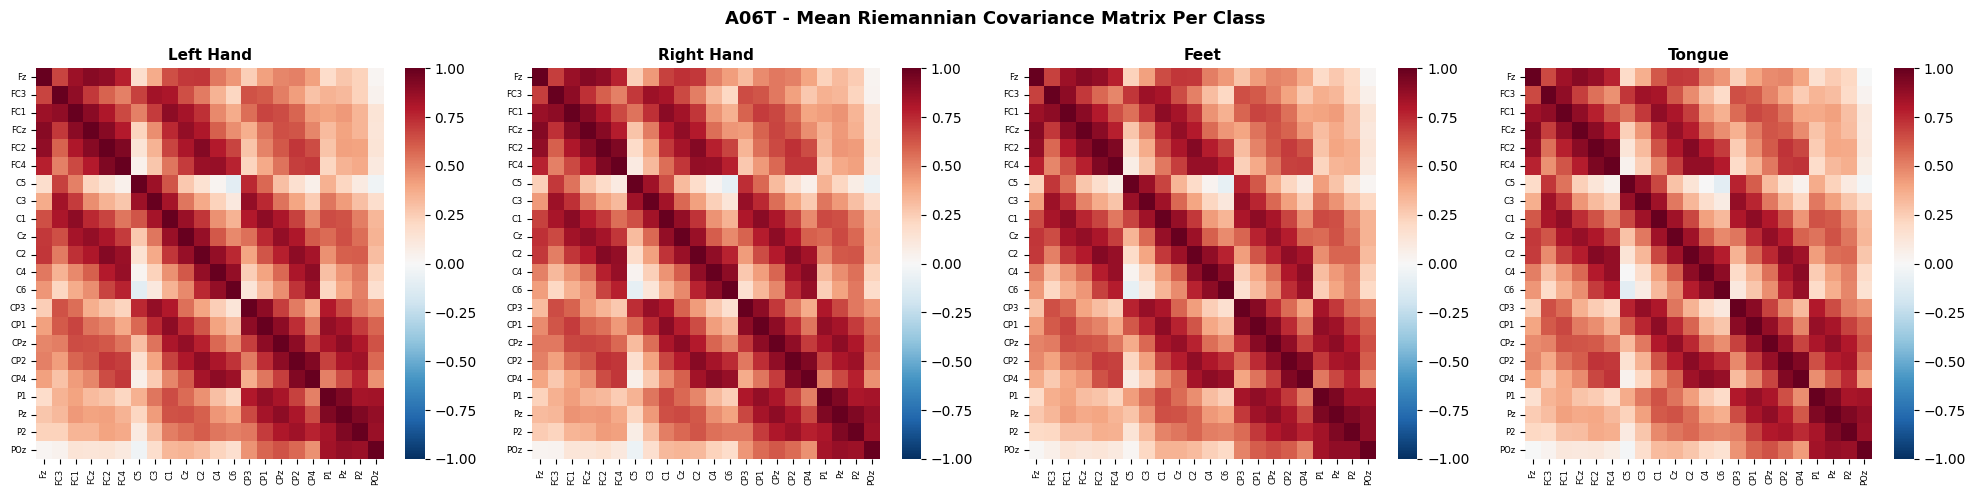

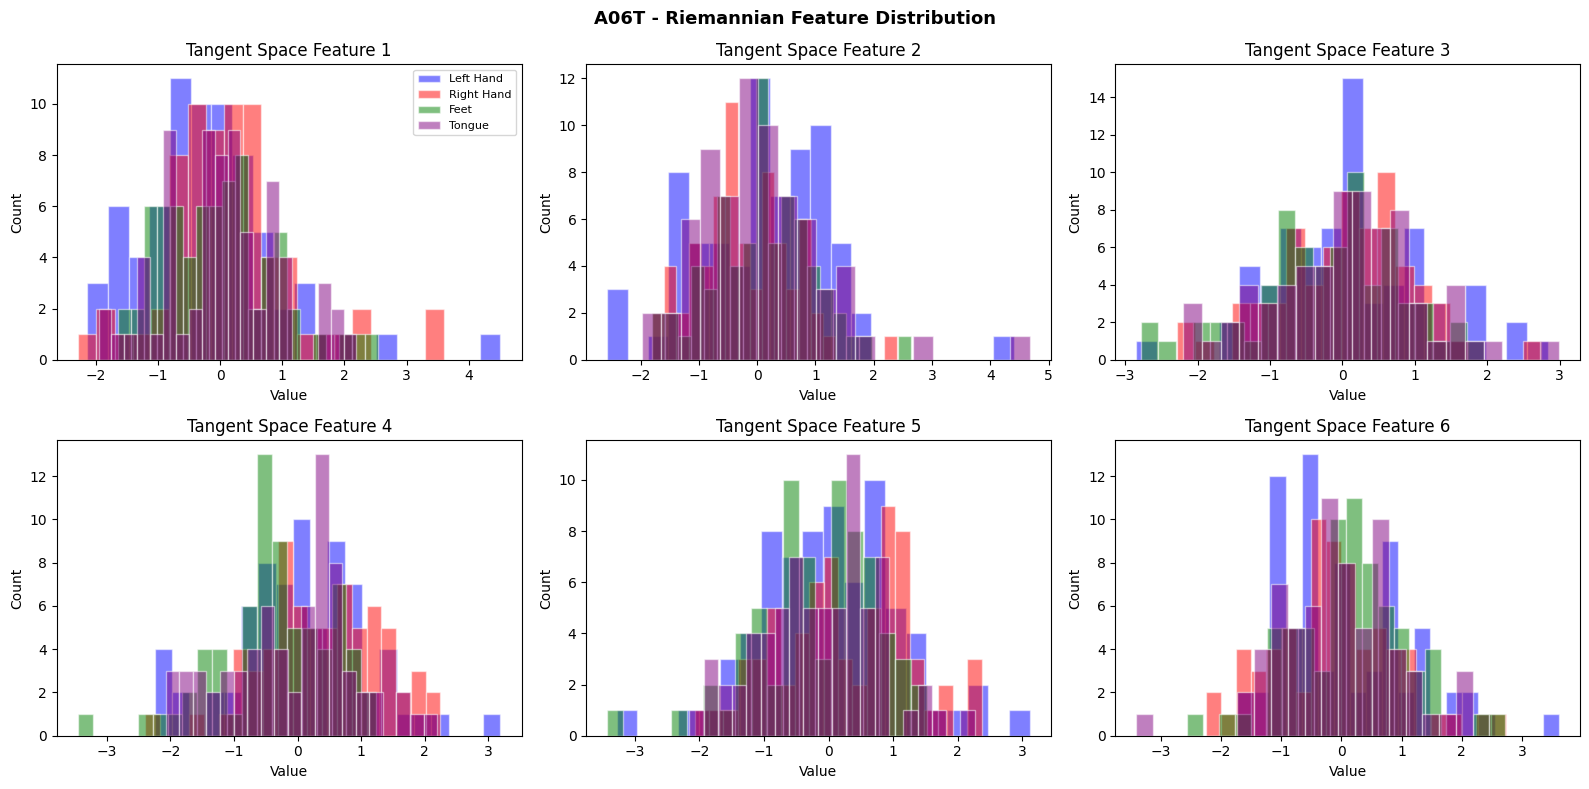

  Plots saved for A06T
  Done: A06T

  A07T
  No bad trials found
  X shape:        (146, 22, 751)
  y distribution: [34 39 39 34]
  Covariance matrices shape: (146, 22, 22)
  Tangent space features shape: (146, 253)
  Saved to ../data/features_riemannian/A07T_riemannian.npz
  Generating Riemannian plots for A07T...


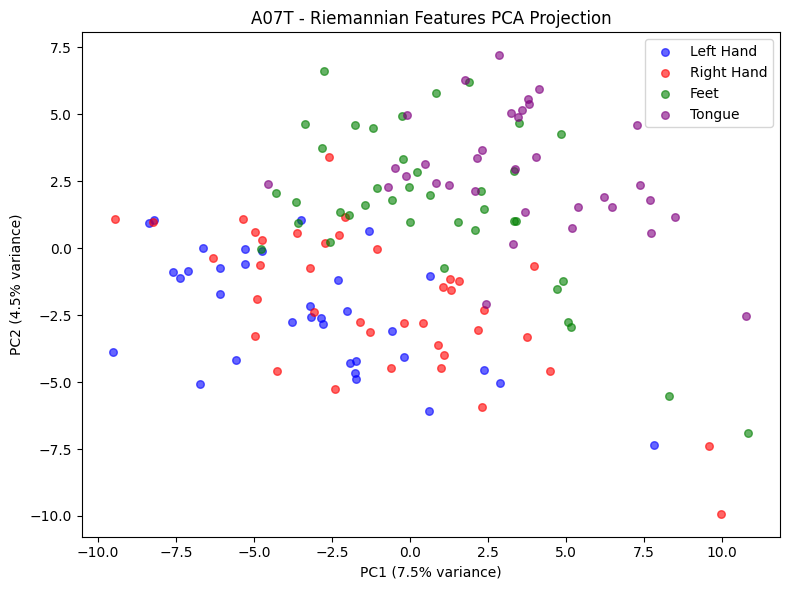

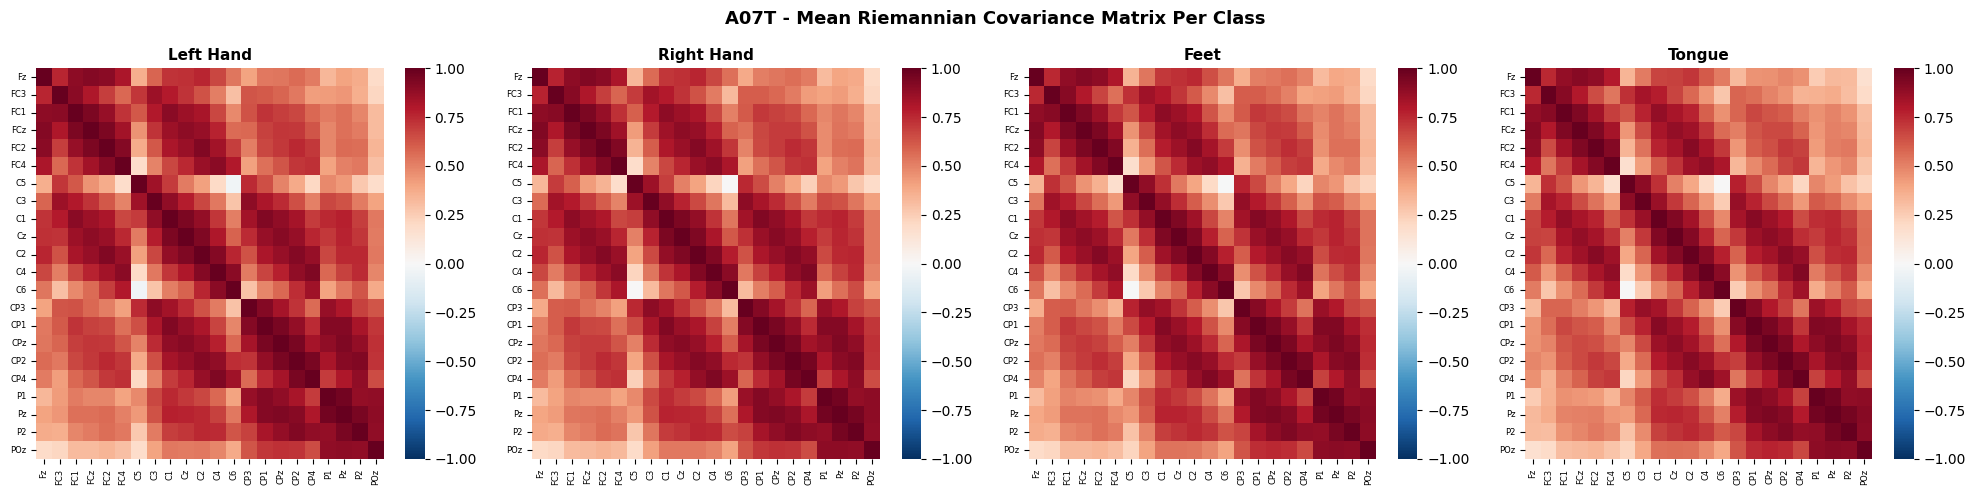

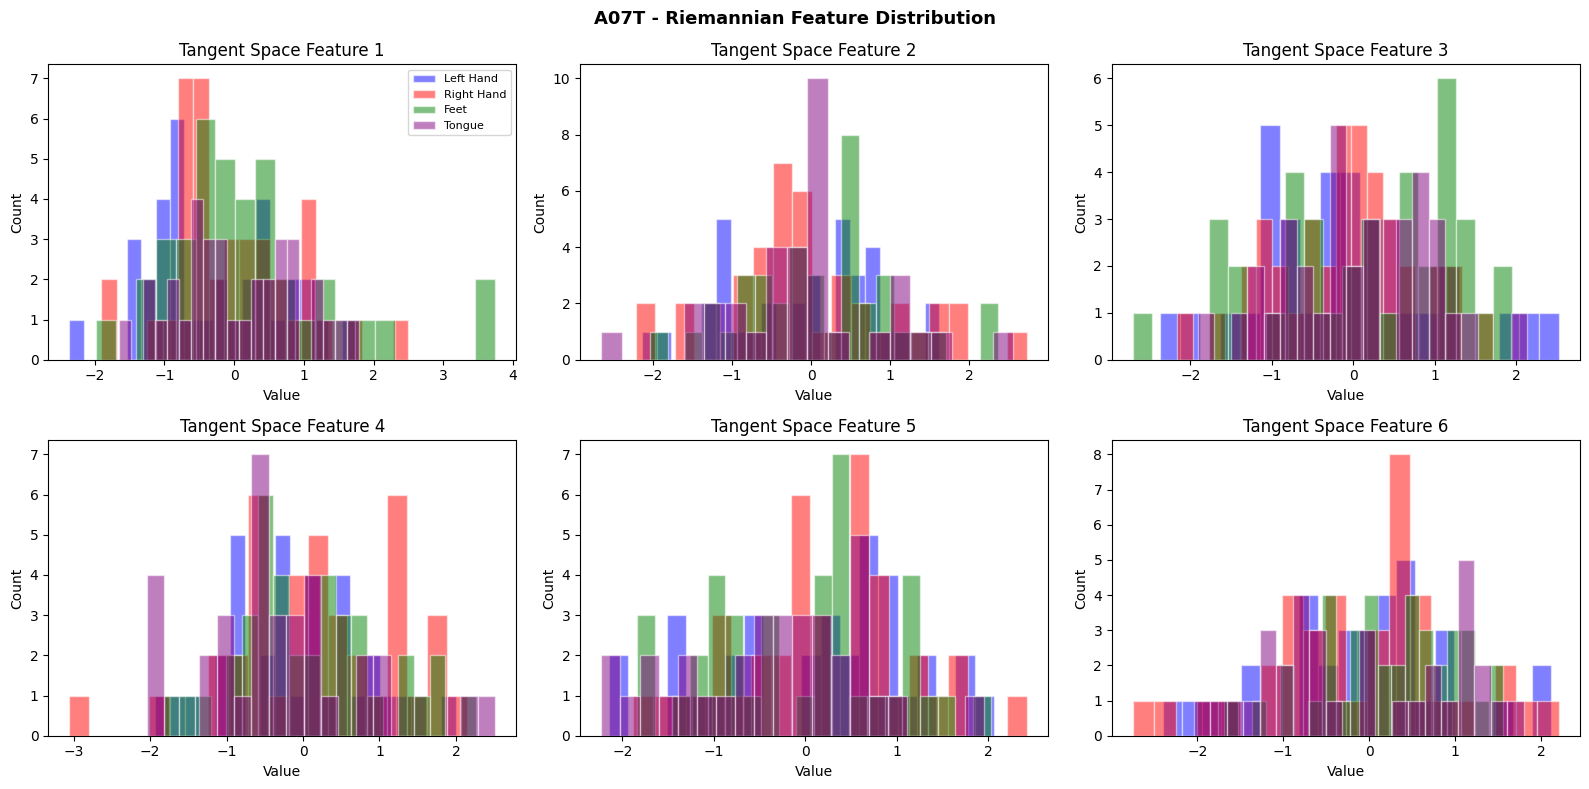

  Plots saved for A07T
  Done: A07T

  A08T
  No bad trials found
  X shape:        (241, 22, 751)
  y distribution: [52 55 65 69]
  Covariance matrices shape: (241, 22, 22)
  Tangent space features shape: (241, 253)
  Saved to ../data/features_riemannian/A08T_riemannian.npz
  Generating Riemannian plots for A08T...


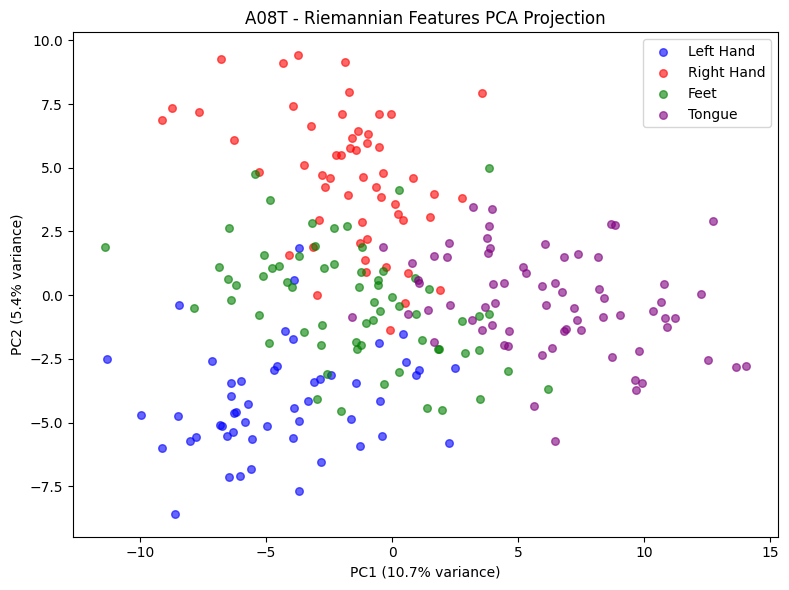

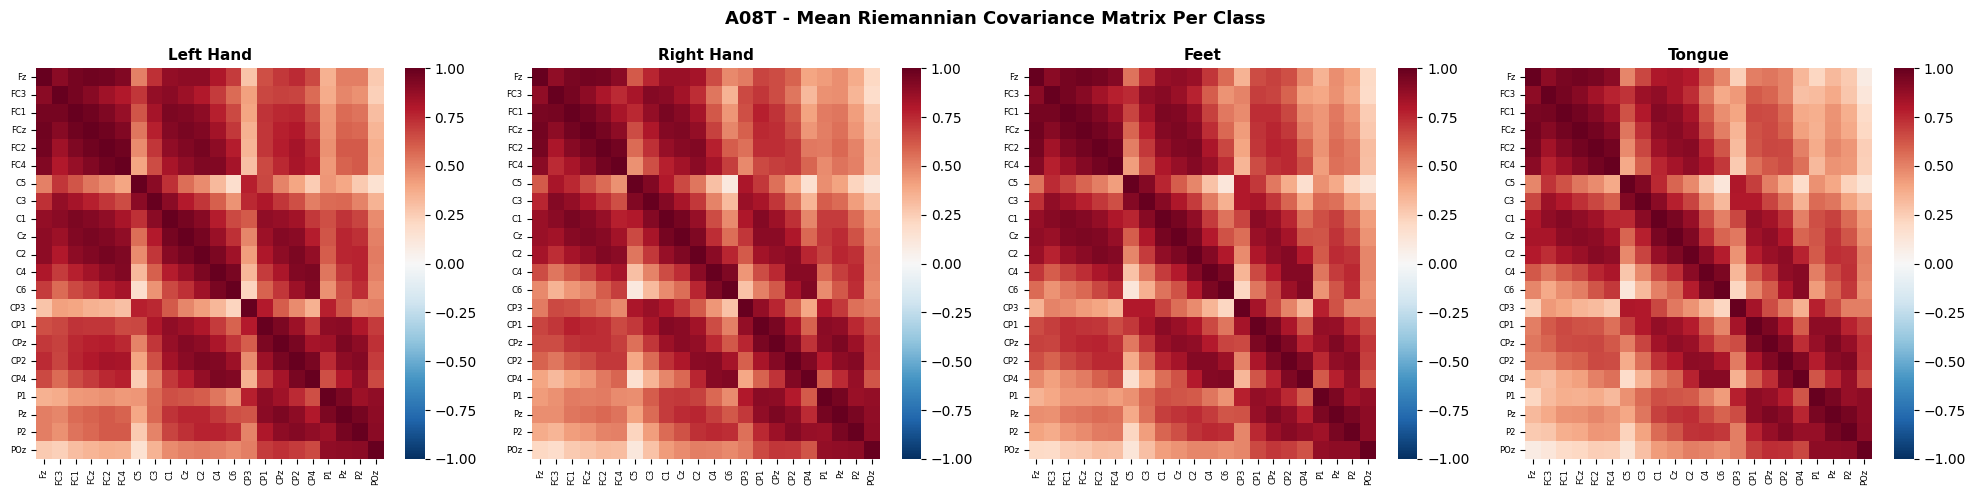

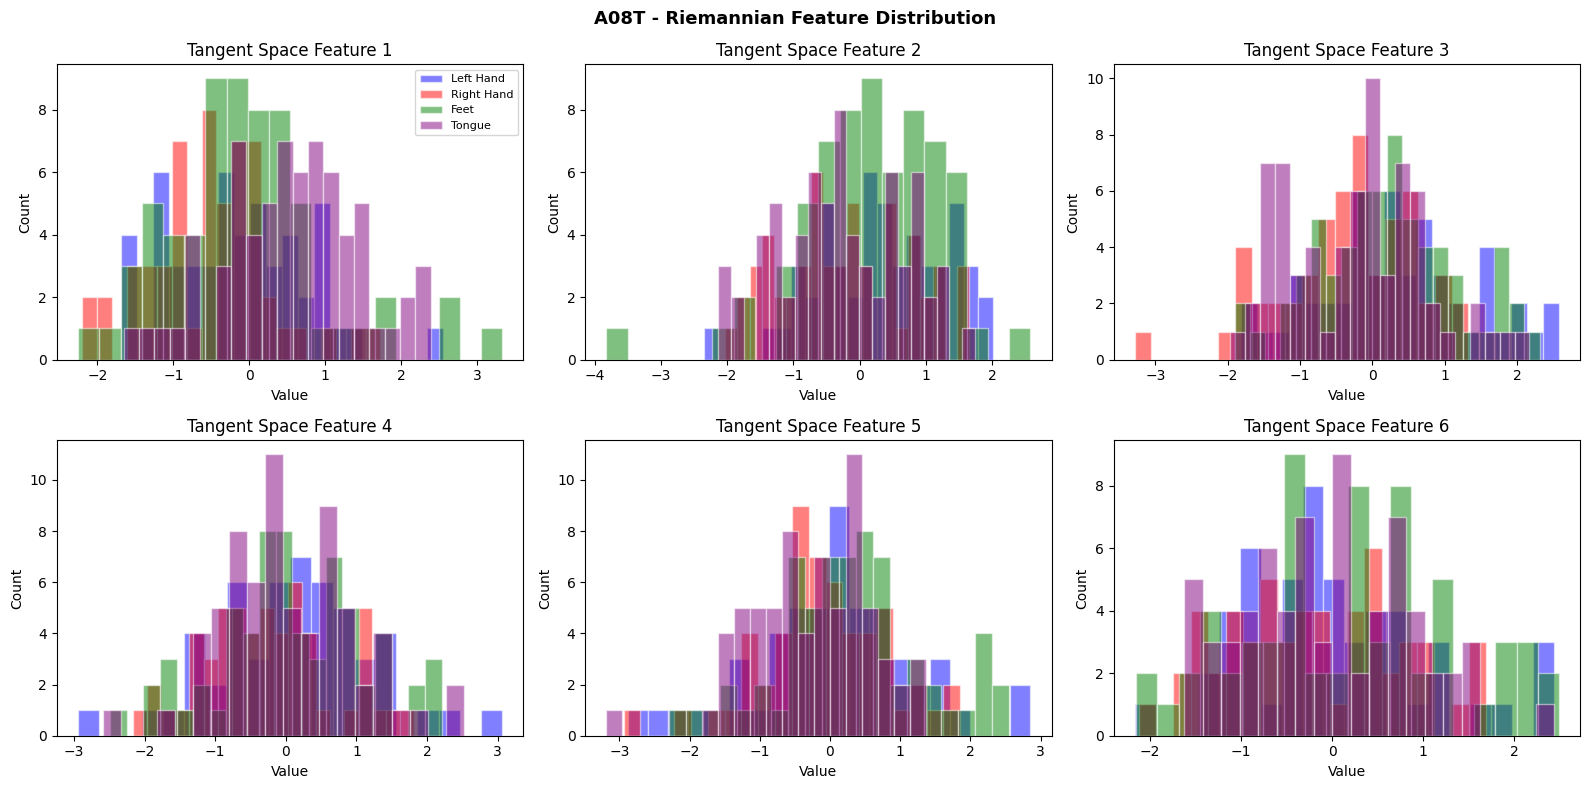

  Plots saved for A08T
  Done: A08T

  A09T
  No bad trials found
  X shape:        (171, 22, 751)
  y distribution: [48 43 40 40]
  Covariance matrices shape: (171, 22, 22)
  Tangent space features shape: (171, 253)
  Saved to ../data/features_riemannian/A09T_riemannian.npz
  Generating Riemannian plots for A09T...


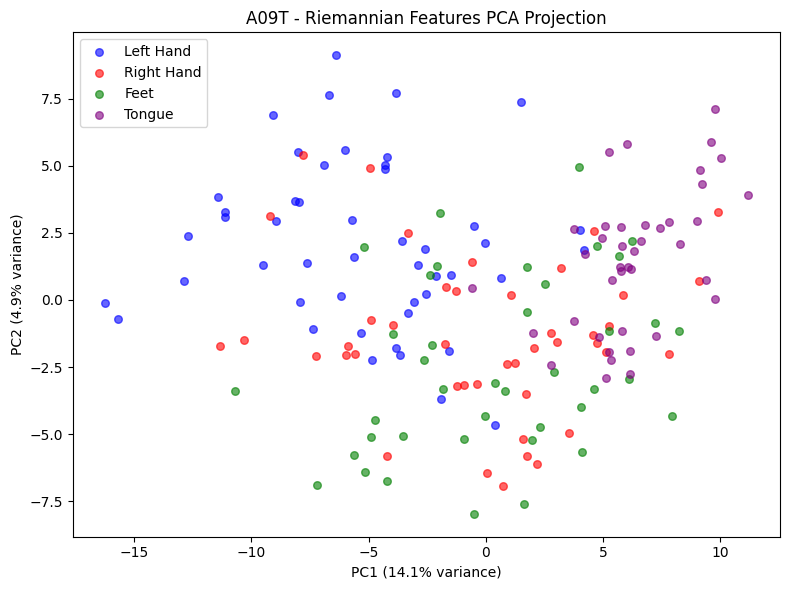

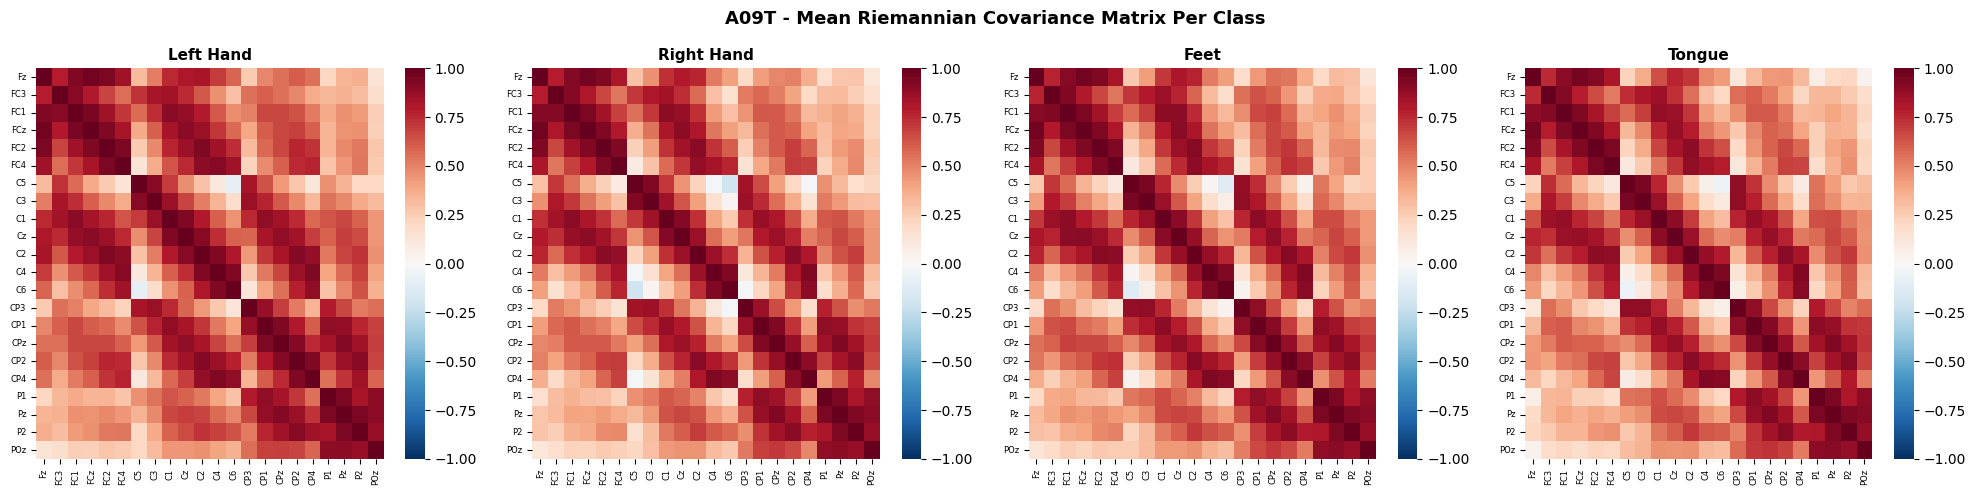

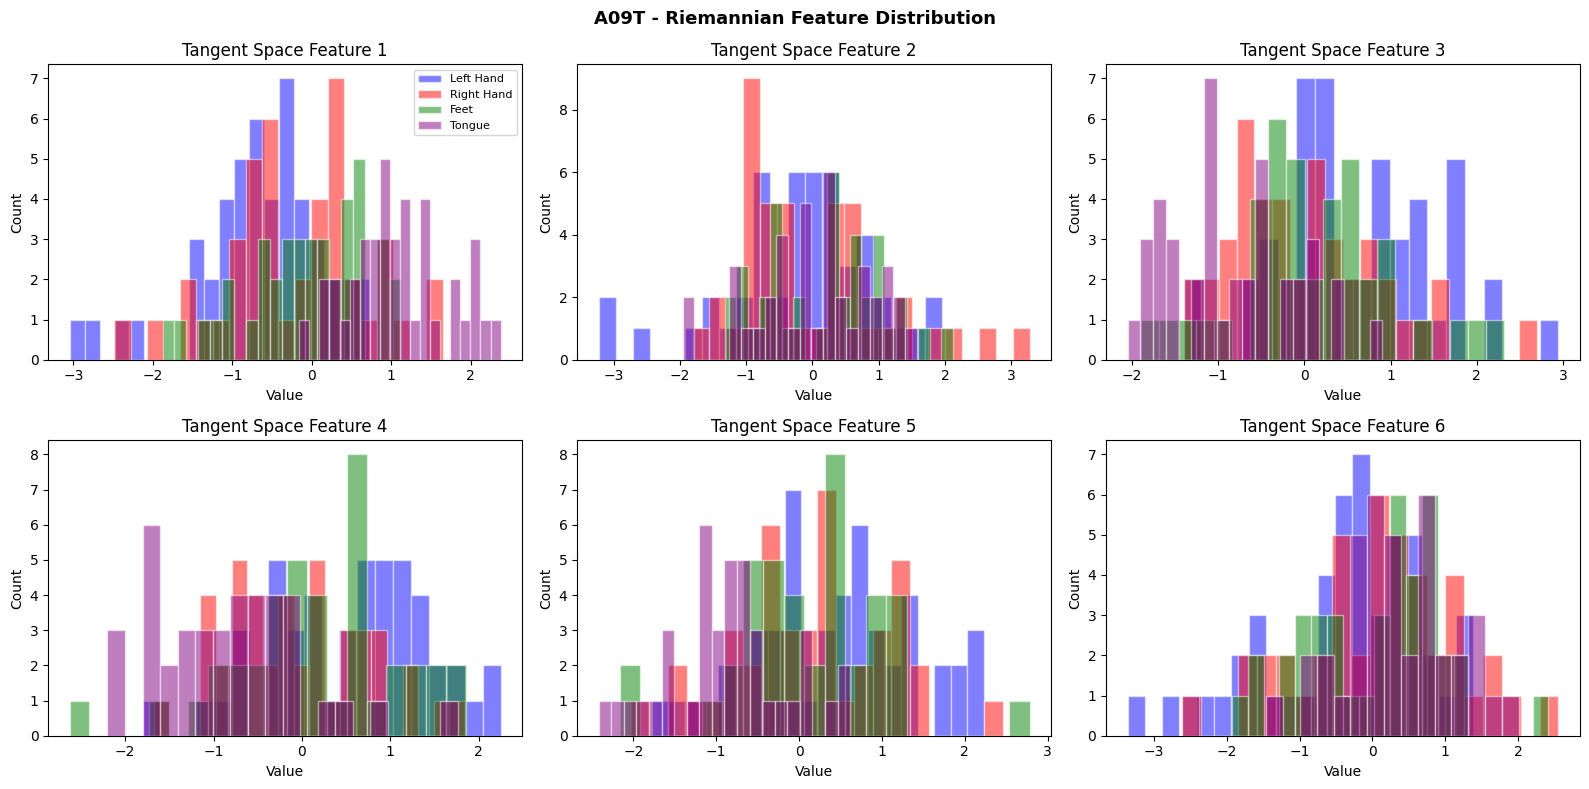

  Plots saved for A09T
  Done: A09T

All subjects done.


In [5]:
riemannian_objects = {}

for subject_id in subjects:
    print(f"\n{'='*50}")
    print(f"  {subject_id}")
    print(f"{'='*50}")

    epochs_final = mne.read_epochs(
        f'{LOAD_PATH}{subject_id}_clean_epo.fif',
        preload=True,
        verbose=False
    )

    X_ts, y, X_cov, cov_est, ts, scaler, le = extract_riemannian_features(epochs_final)
    save_riemannian_features(subject_id, X_ts, y, save_path=SAVE_PATH)
    visualize_riemannian(X_ts, X_cov, y, subject_id,
                         epochs_final.info, figures_path=FIGURES_PATH)

    riemannian_objects[subject_id] = {
        'X':      X_ts,
        'y':      y,
        'X_cov':  X_cov,
        'cov':    cov_est,
        'ts':     ts,
        'scaler': scaler,
        'le':     le
    }

    print(f"  Done: {subject_id}")

print("\nAll subjects done.")

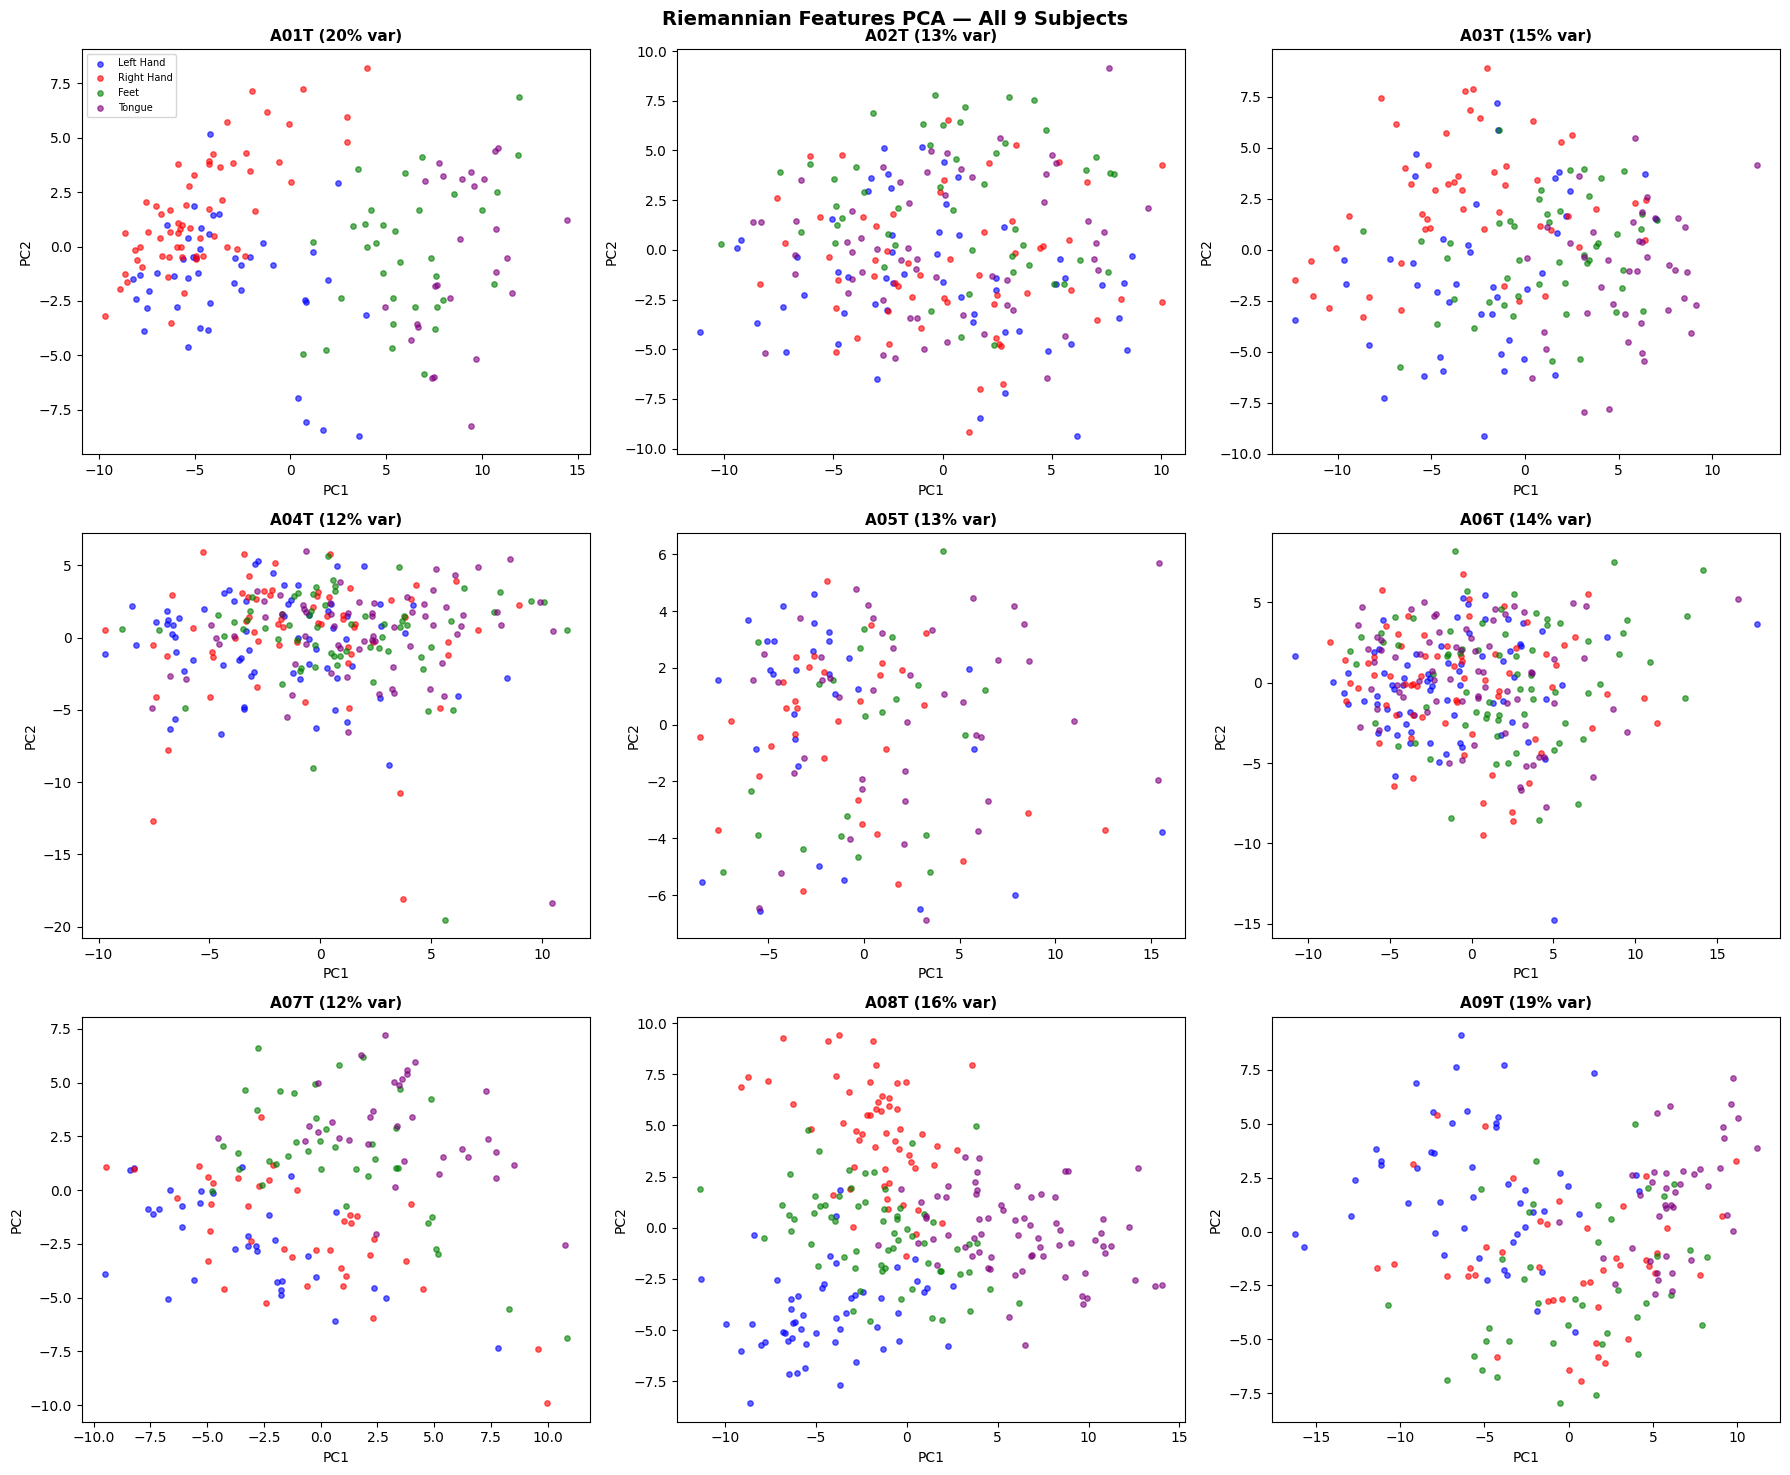

In [6]:
# Cross subject PCA scatter comparison

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
colors    = ['blue', 'red', 'green', 'purple']

for ax, subject_id in zip(axes.flat, subjects):
    X    = riemannian_objects[subject_id]['X']
    y    = riemannian_objects[subject_id]['y']
    pca  = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    var  = pca.explained_variance_ratio_.sum() * 100

    for cls_idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
        mask = y == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=cls_name, alpha=0.6, s=15)

    ax.set_title(f'{subject_id} ({var:.0f}% var)', fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    if subject_id == 'A01T':
        ax.legend(fontsize=7)

plt.suptitle('Riemannian Features PCA — All 9 Subjects',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}all_subjects_riemannian_scatter.png', dpi=100)
plt.show()

In [7]:
import os

print("Riemannian feature files in data/features_riemannian/:")
print()
for subject_id in subjects:
    path = f'../data/features_riemannian/{subject_id}_riemannian.npz'
    if os.path.exists(path):
        X, y = load_riemannian_features(subject_id, load_path=SAVE_PATH)
    else:
        print(f"  {subject_id} - MISSING")

Riemannian feature files in data/features_riemannian/:

  Loaded A01T: X=(164, 253), y=(164,)
  Loaded A02T: X=(216, 253), y=(216,)
  Loaded A03T: X=(179, 253), y=(179,)
  Loaded A04T: X=(262, 253), y=(262,)
  Loaded A05T: X=(127, 253), y=(127,)
  Loaded A06T: X=(282, 253), y=(282,)
  Loaded A07T: X=(146, 253), y=(146,)
  Loaded A08T: X=(241, 253), y=(241,)
  Loaded A09T: X=(171, 253), y=(171,)
